In [212]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #cbcaf0; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Stokes Equations on an Exchanger Device</h3>
</div>

Imports:

In [227]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.path import Path
from matplotlib.patches import Polygon

from Solvers.Exchanger_Device import compute_U_P_solution_exchanger_device

from Utilities.Stokes_felib import (
    calculate_velocity_A,
    calculate_pressure_B,
    calculate_Saddle_point_K,
    calculate_mass_M
)

from Utilities.Mesh_processing import (
    refine
)

from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes,
    Plot_Velocity_and_Pressure,
    K_matrix_structure,
    plot_streamlines,
    plot_pressure
)

---

### Inlet profile exploration:
This code defines a quadratic profile function and identifies mesh boundary nodes corresponding to the inlet, outlet, and solid walls based on spatial coordinate extrema. It isolates wall and inlet nodes to assemble the complete set of Dirichlet boundary nodes required for the numerical simulation. Finally, it initializes velocity vectors and prescribes a parabolic flow profile across the horizontal inlet boundary.

---

Mesh:

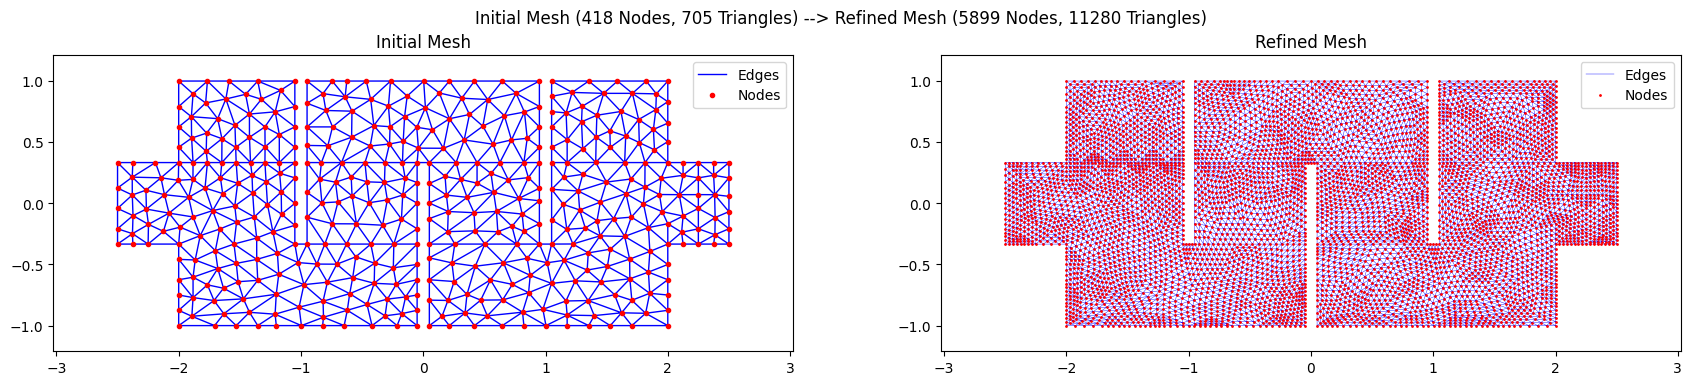

In [214]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(
    data_path='Meshes/exchanger_device_altered_mesh_data.npz',
    num_of_refinements=2,
    figsize=(21, 4),
    plot=True
)
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

Inlet profile:

In [215]:
def parabolic_inlet_profile(x, x_1, x_2, alpha):
    return -alpha*(x - x_1)*(x - x_2)

Nv = p_fine.shape[0]
Np = p_coarse.shape[0]
eps = 1e-10   

xmin = p_fine[:, 0].min()
xmax = p_fine[:, 0].max()

inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

corner_idx  = [inlet_idx[np.argmax(p_fine[inlet_idx, 1])], 
               inlet_idx[np.argmin(p_fine[inlet_idx, 1])]]

boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))
dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))

lf_x = np.zeros(Nv)
lf_y = np.zeros(Nv)

y_inlet = p_fine[inlet_idx, 1]
y_top, y_bottom = p_fine[corner_idx[0], 1], p_fine[corner_idx[1], 1]
lf_x[inlet_idx] = parabolic_inlet_profile(y_inlet, y_top, y_bottom, alpha=3)

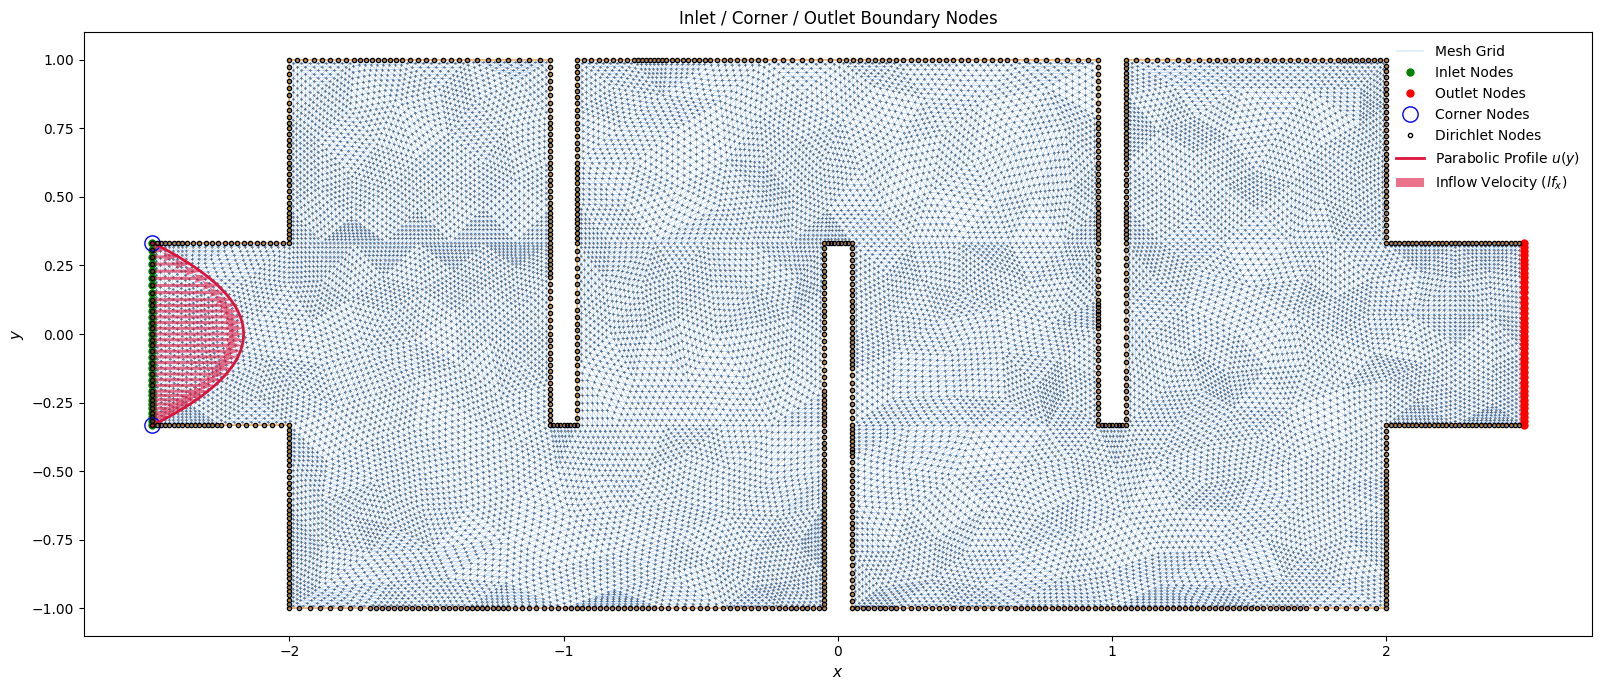

In [216]:
fig, ax = plt.subplots(figsize=(21, 7))

ax.triplot(p_fine[:, 0], p_fine[:, 1], t_fine[:, :3], color='#4A90E2', lw=0.3, alpha=0.7, label='Mesh Grid')
ax.plot(p_fine[:, 0], p_fine[:, 1], 'o', color='k', markersize=0.3, alpha=1)
ax.plot(p_fine[inlet_idx, 0],  p_fine[inlet_idx, 1],  'go', markersize=5, zorder=5, label='Inlet Nodes')
ax.plot(p_fine[outlet_idx, 0], p_fine[outlet_idx, 1], 'ro', markersize=5, zorder=5, label='Outlet Nodes')
ax.plot(p_fine[corner_idx, 0], p_fine[corner_idx, 1], 'bo', markersize=11, zorder=7, markerfacecolor='none', label='Corner Nodes')
ax.plot(p_fine[dirichlet_nodes, 0], p_fine[dirichlet_nodes, 1], 'ko', markersize=3, zorder=10, markerfacecolor='none', label='Dirichlet Nodes')

sort_perm = np.argsort(y_inlet)
ax.plot(xmin + lf_x[inlet_idx][sort_perm], y_inlet[sort_perm], color='crimson', lw=2, zorder=8, label='Parabolic Profile $u(y)$')
ax.quiver(p_fine[inlet_idx, 0], y_inlet, lf_x[inlet_idx], np.zeros_like(y_inlet), angles='xy', scale_units='xy', scale=1, color='crimson', alpha=0.6, width=0.002, zorder=6, label=r'Inflow Velocity ($lf_x$)')

flag1_mask = (e_coarse[:, -1] == 1)
boundary_edges = e_coarse[flag1_mask, :2].astype(int)
x_coords = p_coarse[boundary_edges, 0].T
y_coords = p_coarse[boundary_edges, 1].T

ax.plot(x_coords, y_coords, color="#FF9100", linewidth=1.5, alpha = 0.5)

ax.set_aspect('equal')
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$y$', fontsize=11)
ax.set_title('Inlet / Corner / Outlet Boundary Nodes', fontsize=12)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax.grid(False)

plt.tight_layout()
plt.savefig("Outputs/Conditioning_Inlet.png", dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

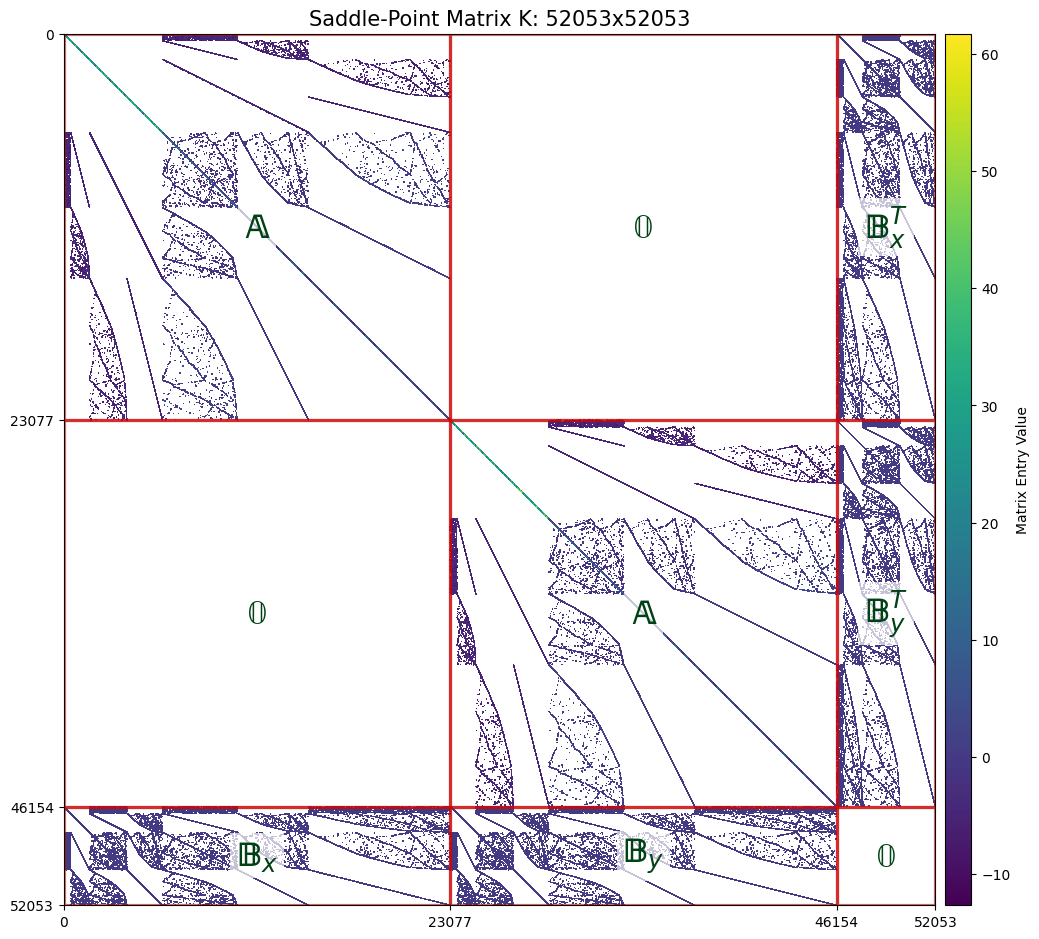

In [217]:
A = calculate_velocity_A(p_fine, t_fine, 1)
B_x, B_y = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
K = calculate_Saddle_point_K(A, B_x, B_y)
K_matrix_structure(K, A.shape[0], B_x.shape[0], (10.5,10.5))

In [218]:
ux, uy, p_sol = compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine, p_coarse, t_coarse)

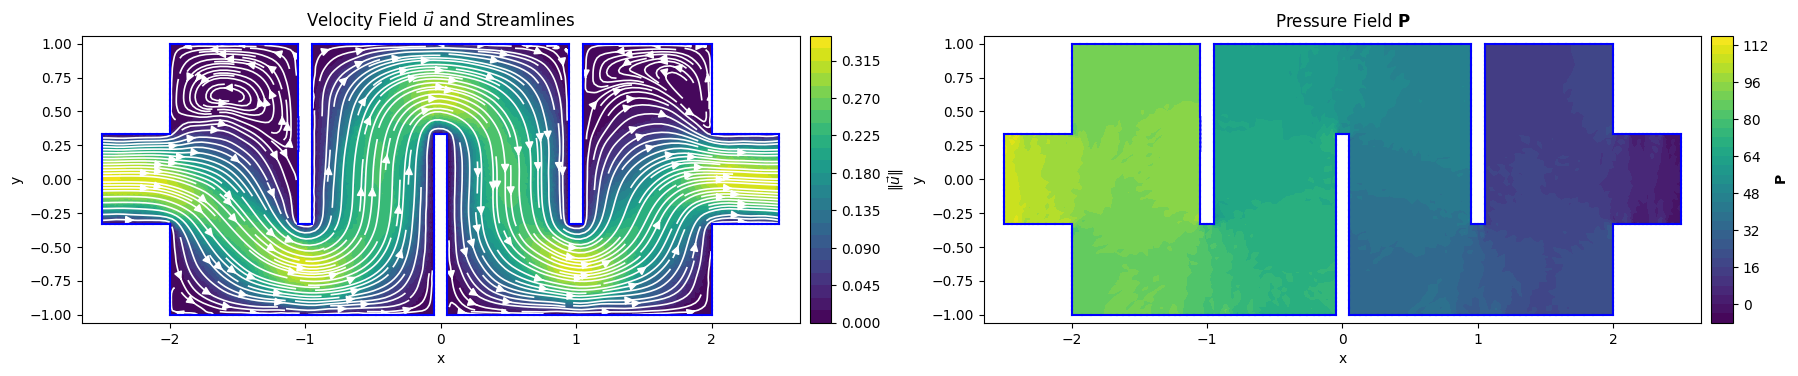

In [219]:
Plot_Velocity_and_Pressure(p_fine, t_fine, p_coarse, t_coarse, e_coarse, ux, uy, p_sol)

---


<div style="background-color: #7aefe9; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0; color: #11116e">Quantities of Interest</h3>
</div>

At first we want to look at regions $-$ where they are located and how they look like:

In [220]:
omega_1 = np.array([
    [-2.00, 1/3],
    [-1.05, 1/3],
    [-1.05, 1.0],
    [-2.00, 1.0],
    [-2.00, 1/3]
])

omega_2 = np.array([
    [-0.95, -1/3],
    [-0.05, -1/3],
    [-0.05,  1/3],
    [-0.95,  1/3],
    [-0.95, -1/3]
])

omega_3 = np.array([
    [0.05, -1/3],
    [0.95, -1/3],
    [0.95,  1/3],
    [0.05,  1/3],
    [0.05, -1/3]
])

omega_4 = np.array([
    [1.05, 1/3],
    [2.00, 1/3],
    [2.00, 1.0],
    [1.05, 1.0],
    [1.05, 1/3]
])

main_region = np.array([
    [ 0.95,  1.0],
    [ 0.95, -1/3],
    [ 1.05, -1/3],
    [ 1.05,  1.0],
    [ 2.00,  1.0],
    [ 2.00,  1/3],
    [ 2.50,  1/3],
    [ 2.50, -1/3],
    [ 2.00, -1/3],
    [ 2.00, -1.0],
    [ 0.05, -1.0],
    [ 0.05,  1/3],
    [-0.05,  1/3],
    [-0.05, -1.0],
    [-2.00, -1.0],
    [-2.00, -1/3],
    [-2.50, -1/3],
    [-2.50,  1/3],
    [-2.00,  1/3],
    [-2.00,  1.0],
    [-1.05,  1.0],
    [-1.05, -1/3],
    [-0.95, -1/3],
    [-0.95,  1.0],
    [ 0.95,  1.0]
])

omega_1.shape

(5, 2)

In [221]:
def extract_region(p, t, region_polygon, *nodal_fields):

    centroids = p[t[:, :3]].mean(axis=1)
    tri_mask = Path(region_polygon).contains_points(centroids)
    t_region = t[tri_mask]

    global_node_ids = np.unique(t_region[:, :3])
    p_local = p[global_node_ids]

    remap = np.zeros(p.shape[0], dtype=int)
    remap[global_node_ids] = np.arange(len(global_node_ids))

    t_local = t_region.copy()
    t_local[:, :3] = remap[t_region[:, :3]]
    
    fields_local = tuple(f[global_node_ids] for f in nodal_fields)

    return p_local, t_local, global_node_ids, fields_local

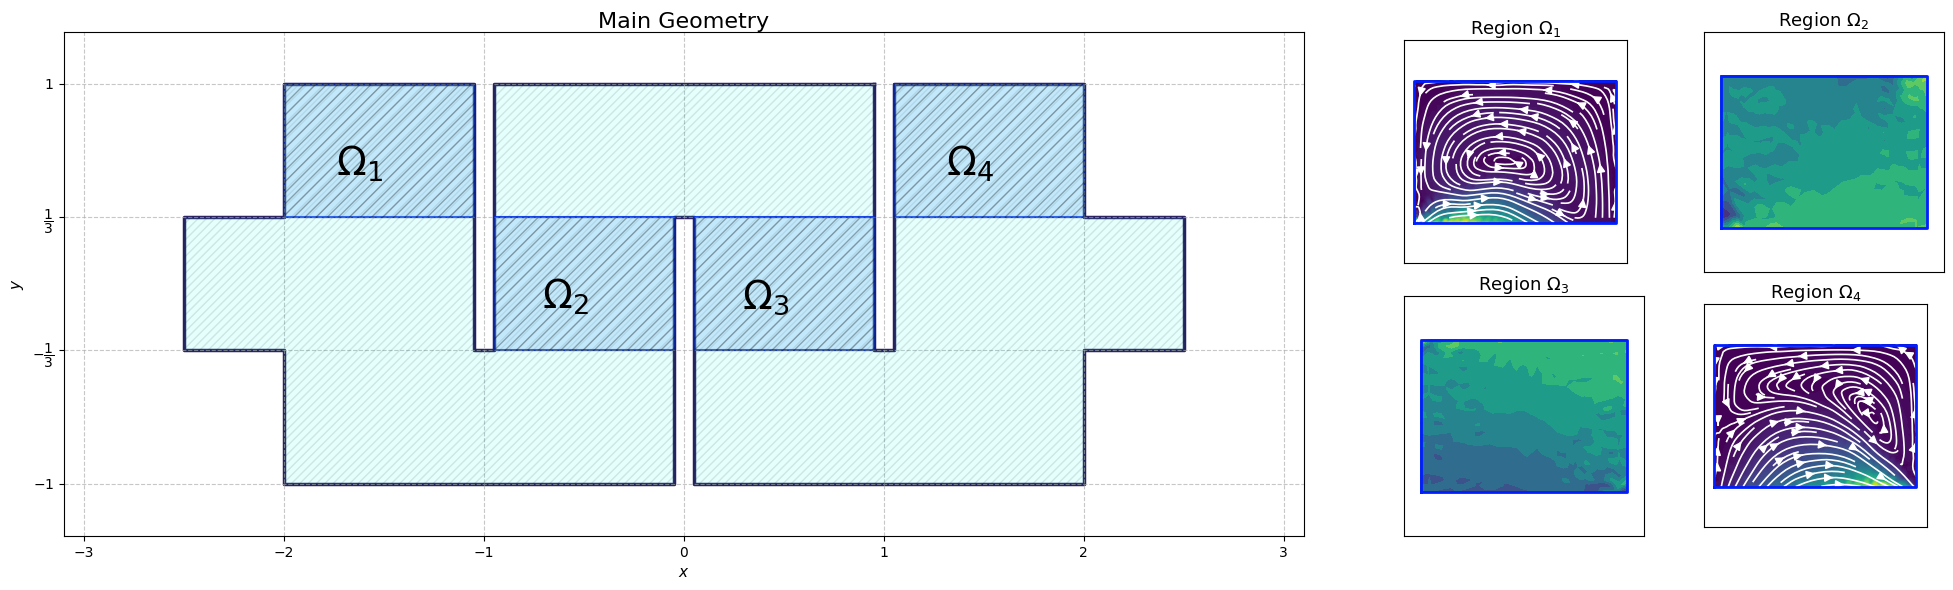

In [222]:
fig = plt.figure(figsize=(20, 6.24))

ax_main      = fig.add_axes([0.030, 0.096, 0.620, 0.808])
ax_top_left  = fig.add_axes([0.700, 0.519, 0.120, 0.385])
ax_top_right = fig.add_axes([0.850, 0.519, 0.120, 0.385])
ax_bot_left  = fig.add_axes([0.700, 0.096, 0.120, 0.385])
ax_bot_right = fig.add_axes([0.850, 0.096, 0.120, 0.385])

sub_axes = [ax_top_left, ax_top_right, ax_bot_left, ax_bot_right]
sub_regions = [omega_1, omega_2, omega_3, omega_4]
labels = ["$\\Omega_1$", "$\\Omega_2$", "$\\Omega_3$", "$\\Omega_4$"]

ax_main.plot(main_region[:, 0], main_region[:, 1], color="#140754", linewidth=2.5, alpha=0.9, zorder=1)
poly_main = Polygon(main_region, closed=True, facecolor="#00FFF2", alpha=0.1, edgecolor=(0, 0, 0, 0.5), hatch='////', zorder=5)
ax_main.add_patch(poly_main)

for sub_reg, text in zip(sub_regions, labels):
    poly = Polygon(sub_reg, closed=True, facecolor="#74B8F7", alpha=0.3, edgecolor=(0, 0, 0, 0.05), hatch='///', zorder=5)
    ax_main.add_patch(poly)
    ax_main.plot(sub_reg[:, 0], sub_reg[:, 1], color="#001EFF", linewidth=1.5, alpha=0.9, zorder=1)

    cx, cy = np.mean(sub_reg, axis=0)
    ax_main.text(cx, cy, text, fontsize=28, ha='center', va='center', zorder=10)

ax_main.set_xlim(-3.1, 3.1)    
ax_main.set_ylim(-1.26, 1.26)  
ax_main.set_aspect('equal')

ax_main.set_xticks(np.linspace(-3, 3, 7))
ax_main.set_yticks([-1, -1/3, 1/3, 1])
ax_main.set_yticklabels(['$-1$', '$-\\dfrac{1}{3}$', '$\\dfrac{1}{3}$', '$1$'])
ax_main.grid(True, which='both', linestyle='--', alpha=0.7)
ax_main.set_xlabel('$x$', fontsize=11)
ax_main.set_ylabel('$y$', fontsize=11)
ax_main.set_title("Main Geometry", fontsize=16, pad=0)


def get_masked_triangulation(p_coords, t_coords, region_poly):
    x, y = p_coords[:, 0], p_coords[:, 1]
    triang = tri.Triangulation(x, y, t_coords[:, :3])
    path = Path(region_poly)
    tri_x = np.mean(x[t_coords[:, :3]], axis=1)
    tri_y = np.mean(y[t_coords[:, :3]], axis=1)
    inside_mask = path.contains_points(np.column_stack((tri_x, tri_y)))
    triang.set_mask(~inside_mask)
    return triang

def get_submesh(p_fine, t_fine, ux, uy, sub_reg):
    x, y = p_fine[:, 0], p_fine[:, 1]
    path = Path(sub_reg)
    tri_x = np.mean(x[t_fine[:, :3]], axis=1)
    tri_y = np.mean(y[t_fine[:, :3]], axis=1)
    mask_tri = path.contains_points(np.column_stack((tri_x, tri_y)))
    
    sub_t = t_fine[mask_tri]
    used_nodes = np.unique(sub_t[:, :3])
    
    node_map = {old: new for new, old in enumerate(used_nodes)}
    
    sub_p = p_fine[used_nodes]
    sub_ux = ux[used_nodes] if ux is not None else None
    sub_uy = uy[used_nodes] if uy is not None else None
    
    sub_t_new = sub_t.copy()
    for i in range(3):
        sub_t_new[:, i] = np.vectorize(node_map.get)(sub_t[:, i])
        
    return sub_p, sub_t_new, sub_ux, sub_uy


SPAN = 1.05

for i, (ax, sub_reg, label) in enumerate(zip(sub_axes, sub_regions, labels)):
    if i in [1, 2]:
        triang_m = get_masked_triangulation(p_coarse, t_coarse, sub_reg)
        ax.tricontourf(triang_m, p_sol, levels=10, cmap='viridis')
        
    else:
        sub_p, sub_t_new, sub_ux, sub_uy = get_submesh(p_fine, t_fine, ux, uy, sub_reg)
        plot_streamlines(sub_p, sub_t_new, ux=sub_ux, uy=sub_uy, ax=ax, density=1)

    ax.plot(sub_reg[:, 0], sub_reg[:, 1], color="#001EFF", linewidth=2.0, zorder=10)
    
    cx, cy = np.mean(sub_reg[:4,:], axis=0)
    ax.set_xlim(cx - SPAN/2, cx + SPAN/2)
    ax.set_ylim(cy - SPAN/2, cy + SPAN/2)
    ax.set_aspect('equal')
    
    ax.grid(False)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(f"Region {label}", fontsize=13, pad=0)

for child_ax in list(fig.axes):
    if child_ax not in [ax_main, ax_top_left, ax_top_right, ax_bot_left, ax_bot_right]:
        child_ax.remove()

plt.savefig("Outputs/Regions.png", dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

---

Curl of a particular region $\Omega_1$ and $\Omega_4$

$$
\omega|_T 
= \frac{1}{\vert{}\mathbf{J}_T\vert{}} \sum_{k=1}^{3} \left[ u_k^y \left( (y_3 - y_1) \frac{\partial \hat{\phi}_k}{\partial \xi_1} - (y_2 - y_1) \frac{\partial \hat{\phi}_k}{\partial \xi_2} \right) - u_k^x \left( (x_2 - x_1) \frac{\partial \hat{\phi}_k}{\partial \xi_2} - (x_3 - x_1) \frac{\partial \hat{\phi}_k}{\partial \xi_1} \right) \right]
$$

$\Omega_1$:

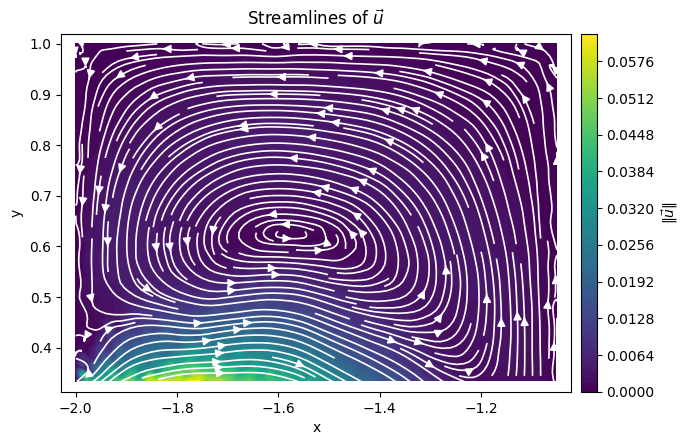

In [223]:
p_local_1, t_local_1, global_node_ids_1, (ux_local_1, uy_local_1) = extract_region(p_fine, t_fine, omega_1, *(ux, uy))
plot_streamlines(p_local_1, t_local_1, ux_local_1, uy_local_1, density=2, figsize=(7,7))

$\Omega_4$:

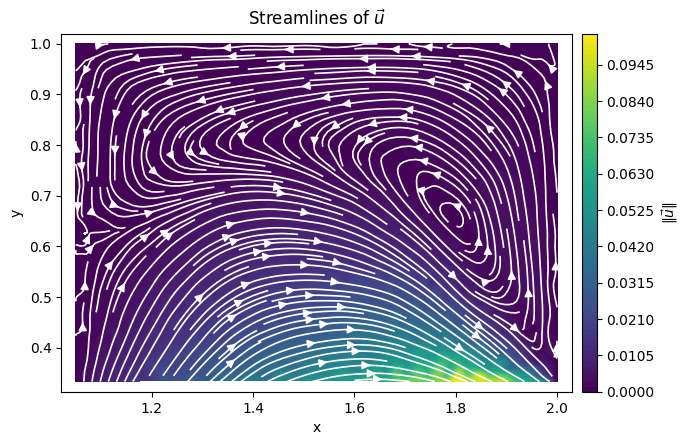

In [224]:
p_local_4, t_local_4, global_node_ids_4, (ux_local_4, uy_local_4) = extract_region(p_fine, t_fine, omega_4, *(ux, uy))
plot_streamlines(p_local_4, t_local_4, ux_local_4, uy_local_4, density=2, figsize=(7,7))

---

Average pressure on region $\Omega_2$ and $\Omega_3$

$$
\bar{p}_{\Omega} 
= \frac{\int_{\Omega} p(x) \, d\Omega}{\int_{\Omega} d\Omega} 
= \frac{1}{(x_2 - x_1)(y_2 - y_1)} \sum_{j=1}^{N_p} p_j \int_{\Omega} \psi_j(x) \, dx
$$

$$
\sum_{k} \int_{T} \psi_j \psi_k \, d\Omega 
= \int_{T} \psi_j \cdot 1 \, d\Omega \implies \int_{\Omega} \psi_j \, d\Omega 
= \sum_{k} (\mathbf{M}_p)_{jk} = (\mathbf{M}_p \mathbf{1})_j
$$

In [263]:
def compute_avg_pressure_of_a_region(p_local, t_local, pressure_local, region_polygon):

    M_p2 = calculate_mass_M(p_local, t_local)

    width  = region_polygon[:, 0].max() - region_polygon[:, 0].min()
    height = region_polygon[:, 1].max() - region_polygon[:, 1].min()
    area   = width * height

    p_avg_2 = pressure_local @ M_p2 @ np.ones(p_local.shape[0]) / area

    return p_avg_2

$\Omega_2$:

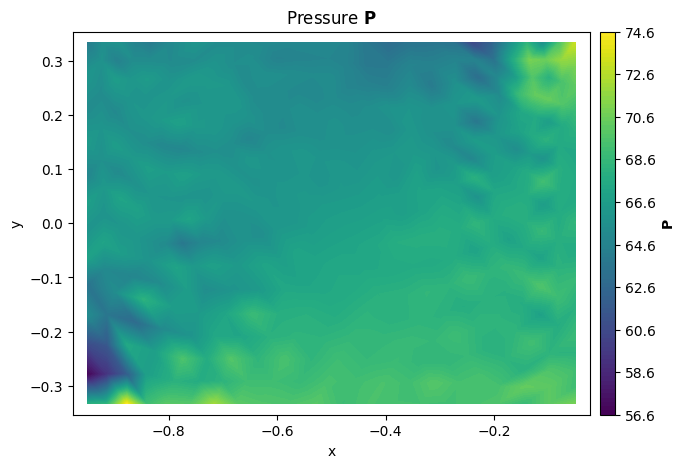

In [264]:
p_local_2, t_local_2, global_node_ids_2, (pressure_local_2,) = extract_region(p_coarse, t_coarse, omega_2, *(p_sol,))
plot_pressure(p_local_2, t_local_2, pressure_local_2, figsize=(7,7))

In [265]:
compute_avg_pressure_of_a_region(p_local_2, t_local_2, pressure_local_2, omega_2)

66.77395977167305

$\Omega_3$:

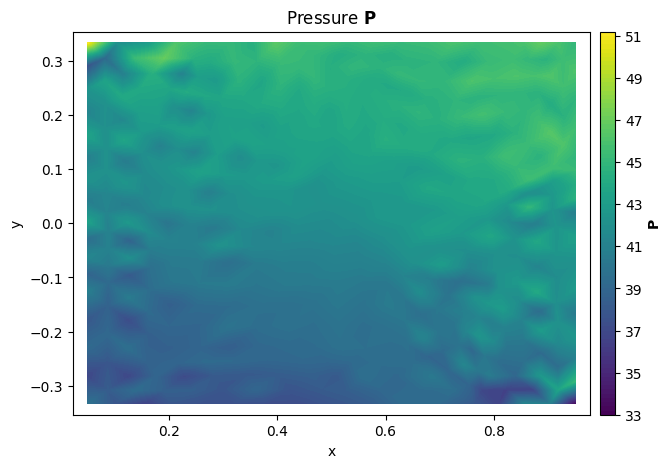

In [266]:
p_local_3, t_local_3, global_node_ids_3, (pressure_local_3,) = extract_region(p_coarse, t_coarse, omega_3, *(p_sol,))
plot_pressure(p_local_3, t_local_3, pressure_local_3, figsize=(7,7))

In [267]:
compute_avg_pressure_of_a_region(p_local_3, t_local_3, pressure_local_3, omega_3)

41.858129420148764

---